### Importing libraries

In [46]:
import os
import cupy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neo
from scipy.signal import butter, filtfilt, hilbert, iirnotch, welch, find_peaks
from scipy.integrate import trapezoid
from scipy.fft import fft, ifft

### Setup and Load Data using Neo (BlackrockIO)

In [ ]:
# Directory and file configuration
data_dir = "C:\\Users\\Andres\\OneDrive\\Documentos\\Anaconda\\LFP_analysis"
filename = "20230522-090311-001.ns2" 
file_path = os.path.join(data_dir, filename)

if not os.path.exists(file_path):
    raise FileNotFoundError(f"The file {filename} was not found in {data_dir}")

# Load continuous data using Neo BlackrockIO reader
reader = neo.io.BlackrockIO(file_path)
block = reader.read_block()
analog_signal = block.segments[0].analogsignals[0]

# Extract basic properties
fs = int(analog_signal.sampling_rate)  
num_channels = analog_signal.shape[1]

# Transfer data to GPU using CuPy and transpose to get (channels, samples)
signal_data_gpu = cp.array(analog_signal).T

print(f"File loaded successfully: {filename}")
print(f"Sampling Frequency (fs): {fs} Hz")
print(f"Number of Channels: {num_channels}")
print(f"Total Samples: {signal_data_gpu.shape[1]}")

File loaded successfully: 20230522-090311-001.ns2
Sampling Frequency (fs): 1000 Hz
Number of Channels: 39
Total Samples: 1810010


### Baseline Data Exploration and Descriptive Statistics

In [4]:
# Bring a small segment to CPU for Pandas DataFrame exploration
# Let's explore the first 5 seconds of data (5000 samples at 1000Hz)
max_samples_to_explore = min(5000, signal_data_gpu.shape[1])
time_array_cpu = np.linspace(0, max_samples_to_explore / fs, max_samples_to_explore)
signal_segment_cpu = cp.asnumpy(signal_data_gpu[:, :max_samples_to_explore].T)

# Create channel names dynamically for all 32 channels
channel_names = [f"CH_{i}" for i in range(num_channels)]

# Construct exploration DataFrame
df_exploration = pd.DataFrame(signal_segment_cpu, columns=channel_names)
df_exploration.insert(0, 'Time (s)', time_array_cpu)
df_exploration.set_index('Time (s)', inplace=True)

print("=== 32-CHANNEL LFP DATAFRAME PREVIEW ===")
display(df_exploration.head(10))

print("\n=== DATA DESCRIPTIVE STATISTICS (ALL CHANNELS) ===")
display(df_exploration.describe())

=== 32-CHANNEL LFP DATAFRAME PREVIEW ===


,CH_0,CH_1,CH_2,CH_3,CH_4,CH_5,CH_6,CH_7,CH_8,CH_9,...,CH_29,CH_30,CH_31,CH_32,CH_33,CH_34,CH_35,CH_36,CH_37,CH_38
Time (s),,,,,,,,,,,,,,,,,,,,,
0.000000,39.50,32.50,-11.25,11.50,49.50,42.50,2.00,-1.50,8.50,35.25,...,-9.50,207.50,227.25,30.0,7.0,14.5,22.5,18.75,53.75,-28.25
0.001000,69.25,9.75,-32.50,-20.25,8.25,42.25,-28.00,2.50,-29.75,3.50,...,12.75,159.75,194.50,30.0,7.0,-29.5,14.5,23.00,0.50,-28.25
0.002000,55.75,28.50,-16.50,5.00,20.00,26.00,-22.00,-5.75,-9.00,34.25,...,33.00,159.25,199.00,20.0,-3.0,-29.5,14.5,23.00,0.50,11.50
0.003001,34.50,69.25,26.50,48.50,52.50,13.00,19.00,24.00,13.00,61.50,...,47.75,116.50,155.00,20.0,-3.0,-26.5,-1.5,14.00,44.75,11.50
0.004001,40.50,104.00,62.50,81.25,99.25,19.50,43.50,55.25,41.75,80.50,...,27.75,100.75,139.75,24.0,-15.0,-26.5,-1.5,14.00,44.75,-57.75
0.005001,6.50,99.25,58.25,78.25,90.50,-11.75,40.50,44.50,31.00,62.50,...,46.25,74.00,129.00,24.0,-15.0,-13.5,22.5,27.00,-42.50,-57.75
0.006001,36.50,78.50,34.75,51.00,68.50,29.50,32.75,39.50,33.00,50.00,...,46.25,89.25,139.25,1.0,3.0,-13.5,22.5,27.00,-42.50,-2.50
0.007001,17.50,66.25,49.00,76.75,103.00,14.50,53.25,59.50,49.75,80.25,...,9.00,109.25,155.50,1.0,3.0,-35.5,14.5,4.00,-8.25,-2.50
0.008002,28.25,73.50,25.50,46.50,56.75,17.00,31.50,23.00,40.00,52.50,...,23.50,54.50,88.00,24.0,2.0,-35.5,14.5,4.00,-8.25,2.25



=== DATA DESCRIPTIVE STATISTICS (ALL CHANNELS) ===


,CH_0,CH_1,CH_2,CH_3,CH_4,CH_5,CH_6,CH_7,CH_8,CH_9,...,CH_29,CH_30,CH_31,CH_32,CH_33,CH_34,CH_35,CH_36,CH_37,CH_38
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,...,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,-30.094801,-46.663200,-48.974449,-41.854698,-19.424900,-21.309349,-26.051750,-25.95645,-18.513599,-13.496750,...,-6.27460,-20.835051,-25.998550,13.015350,-5.402700,2.820400,8.420600,0.449500,0.09525,0.052800
std,104.752357,162.941299,139.195450,137.427246,137.121475,101.974762,121.012138,122.14518,119.446999,147.335938,...,151.47435,182.780655,189.777374,13.668877,17.226858,22.672293,9.068254,12.171717,28.80814,28.180374
min,-424.000000,-700.000000,-591.250000,-602.500000,-553.250000,-384.750000,-482.750000,-501.25000,-461.500000,-468.750000,...,-479.00000,-677.750000,-708.750000,-26.000000,-75.500000,-90.750000,-21.000000,-43.750000,-106.75000,-86.250000
25%,-71.250000,-132.250000,-119.562500,-109.250000,-87.062500,-58.562500,-83.562500,-83.25000,-73.312500,-115.000000,...,-88.31250,-143.500000,-153.250000,3.000000,-15.000000,-12.500000,3.000000,-7.750000,-19.25000,-18.250000
50%,-10.000000,-24.875000,-35.500000,-26.250000,2.750000,1.250000,-10.250000,-9.75000,-2.125000,-3.375000,...,-2.00000,-16.000000,-19.875000,13.000000,-4.500000,3.500000,8.250000,0.500000,-0.50000,0.250000
75%,34.250000,58.750000,37.500000,46.750000,69.750000,35.250000,51.250000,52.75000,57.000000,96.500000,...,82.75000,107.062500,106.500000,22.000000,5.750000,18.500000,13.500000,8.750000,20.00000,19.000000
max,335.750000,445.250000,370.500000,357.000000,347.500000,305.500000,344.250000,307.75000,304.250000,375.500000,...,479.50000,469.250000,511.500000,64.000000,44.750000,71.250000,39.250000,46.500000,108.00000,80.250000


### LFP Stacked Overview (Strictly Channels 0 to 31)

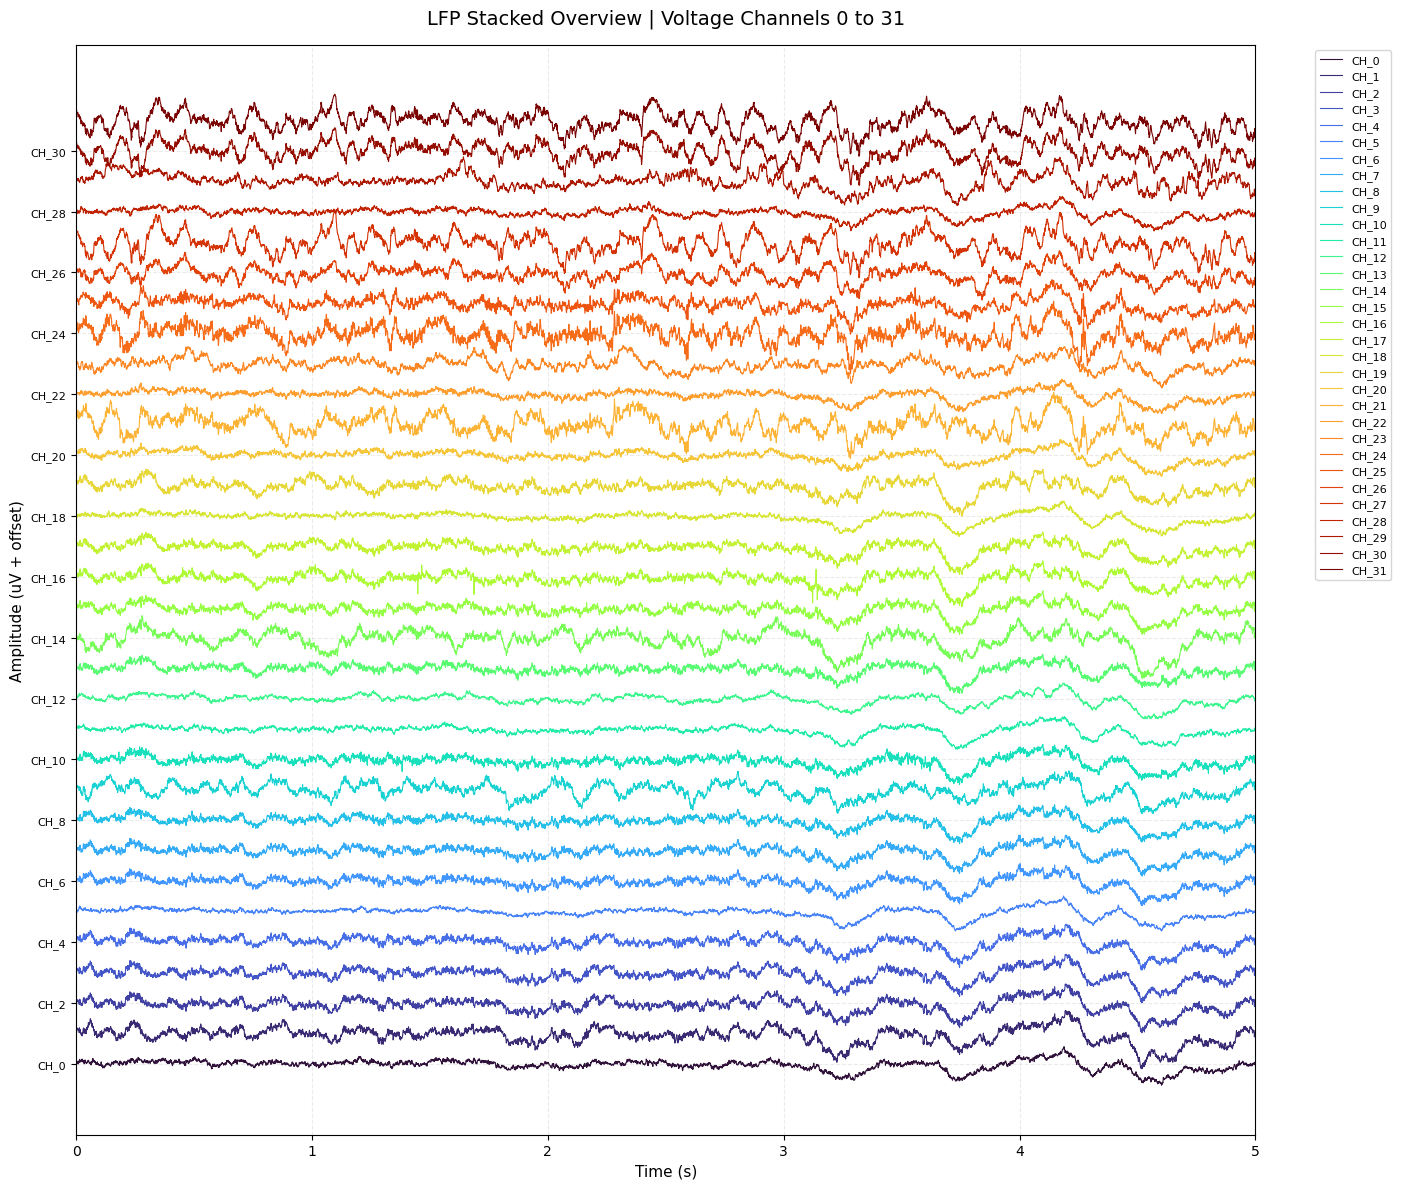

In [16]:
# --- Visualization: First 32 Voltage Channels Stacked ---
t_start, t_stop = 0.0, 5.0
n_plot_channels = 32  # Limited strictly to the 32 real voltage channels
offset_value = 600    # Adjust this value if traces overlap too much

# Slice time window and select only the first 32 channels from exploration DataFrame
df_lfp_real = df_exploration.iloc[:, :n_plot_channels]
df_window = df_lfp_real.loc[t_start:t_stop]

# Apply vertical offset to separate channels cleanly
offsets = np.arange(n_plot_channels) * offset_value
df_offset = df_window + offsets

# Plotting Configuration
fig, ax = plt.subplots(figsize=(14, 12))

# Use a continuous colormap to generate distinct colors for all 32 channels
colors = plt.cm.turbo(np.linspace(0, 1, n_plot_channels))

for i, col in enumerate(df_offset.columns):
    ax.plot(df_offset.index, df_offset[col], color=colors[i], linewidth=0.8, label=col)

# Layout adjustments
ax.set_title(f"LFP Stacked Overview | Voltage Channels 0 to {n_plot_channels-1}", fontsize=14, pad=15)
ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Amplitude (uV + offset)", fontsize=11)
ax.set_xlim(t_start, t_stop)
ax.grid(True, alpha=0.25, linestyle='--')

# Match Y-ticks with channel positions for instant identification
ax.set_yticks(offsets[::2])  # Step by 2 to prevent Y-axis text crowding
ax.set_yticklabels(df_offset.columns[::2], fontsize=8)

# Optimize legend to display in multiple columns without blocking data
ax.legend(loc='upper right', bbox_to_anchor=(1.12, 1.0), ncol=1, fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

### Power Spectral Density (PSD) Analysis (First Channel)

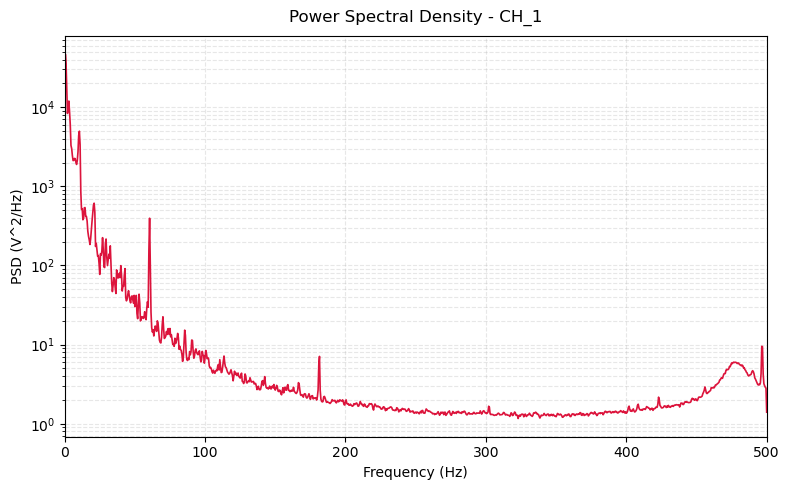

In [17]:
# --- Power Spectral Density (PSD) Analysis ---
from scipy import signal

ch_name = 'CH_1'  # Exploring the first real voltage channel
nperseg_val = int(fs * 2)  # Calculated using your dataset's sampling frequency (1000 Hz)

# Extract full signal from CPU data matrix for CH_1
channel_data = signal_data_cpu[1, :]

frequencies, psd = signal.welch(channel_data, fs=fs, nperseg=nperseg_val)

plt.figure(figsize=(8, 5))
plt.semilogy(frequencies, psd, color='crimson', linewidth=1.2)

# Graph layout and constraints
plt.title(f"Power Spectral Density - {ch_name}", fontsize=12, pad=10)
plt.xlabel("Frequency (Hz)", fontsize=10)
plt.ylabel("PSD (V^2/Hz)", fontsize=10)
plt.xlim(0, 500)  # Capped at 500 Hz (Nyquist limit for fs=1000Hz)
plt.grid(True, which="both", alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### Apply Notch Filter (60 Hz & 180 Hz) on a Specific Channel

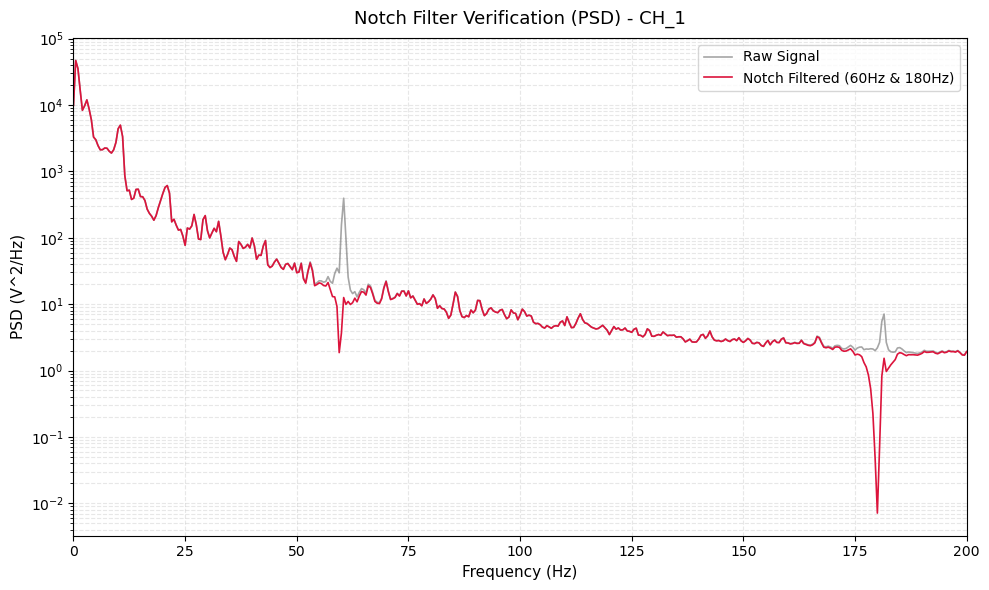

In [ ]:
# Select target channel index (e.g., CH_1 -> index 1)
target_channel_idx = 1
channel_raw = signal_data_cpu[target_channel_idx, :]

# Design Notch Filter for 60 Hz (Standard aggressiveness)
b60, a60 = iirnotch(w0=60.0, Q=30.0, fs=fs)
# Design Notch Filter for 180 Hz (Less aggressive than 60Hz)
b180, a180 = iirnotch(w0=180.0, Q=60.0, fs=fs)

# Apply both filters sequentially to the raw signal
channel_filtered_60 = filtfilt(b60, a60, channel_raw)
channel_notch_final = filtfilt(b180, a180, channel_filtered_60)

# Compute PSD for both raw and filtered signals to verify attenuation
nperseg_val = int(fs * 2)
freqs_raw, psd_raw = welch(channel_raw, fs=fs, nperseg=nperseg_val)
freqs_filt, psd_filt = welch(channel_notch_final, fs=fs, nperseg=nperseg_val)

# Plotting Comparison
plt.figure(figsize=(10, 6))
plt.semilogy(freqs_raw, psd_raw, color='gray', alpha=0.7, linewidth=1.2, label='Raw Signal')
plt.semilogy(freqs_filt, psd_filt, color='crimson', linewidth=1.2, label='Notch Filtered (60Hz & 180Hz)')
plt.title(f"Notch Filter Verification (PSD) - CH_{target_channel_idx}", fontsize=13, pad=10)
plt.xlabel("Frequency (Hz)", fontsize=11)
plt.ylabel("PSD (V^2/Hz)", fontsize=11)
plt.xlim(0, 200)  # Focused window to clearly see 60 Hz and 180 Hz dips
plt.grid(True, which="both", alpha=0.3, linestyle='--')
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Multi-Channel Notch Filtering (60 Hz & 180 Hz)

In [34]:
# Bring data back to CPU for sequential processing
signal_data_cpu = cp.asnumpy(signal_data_gpu)
n_voltage_channels = 32

# Design Notch Filters
b60, a60 = iirnotch(w0=60.0, Q=30.0, fs=fs)   # Standard aggressiveness
b180, a180 = iirnotch(w0=180.0, Q=60.0, fs=fs) # Half as aggressive (Narrower)

# Pre-allocate array for filtered signals (only for the 32 real voltage channels)
filtered_data_cpu = np.zeros((n_voltage_channels, signal_data_cpu.shape[1]))

print("Applying Notch filters (60Hz and 180Hz) to all 32 voltage channels...")
for ch_idx in range(n_voltage_channels):
    ch_filt60 = filtfilt(b60, a60, signal_data_cpu[ch_idx, :])
    filtered_data_cpu[ch_idx, :] = filtfilt(b180, a180, ch_filt60)

print("Filtering complete.")

Applying Notch filters (60Hz and 180Hz) to all 32 voltage channels...
Filtering complete.


### Automatic Determination of the CA1 Pyramidal Layer Channel

Based in Lopes dos Santos et al., 2025

Calculate and Plot Absolute Ripple Power

Computing spectral metrics for 32 channels

=== PYRAMIDAL LAYER CHANNEL DETERMINATION ===
Green Bar -> Reference Channel (Highest Score): CH_16 (Score: 0.5475)
Red Bar   -> Worst Quality Channel (Lowest Score): CH_11 (Score: 0.3771)


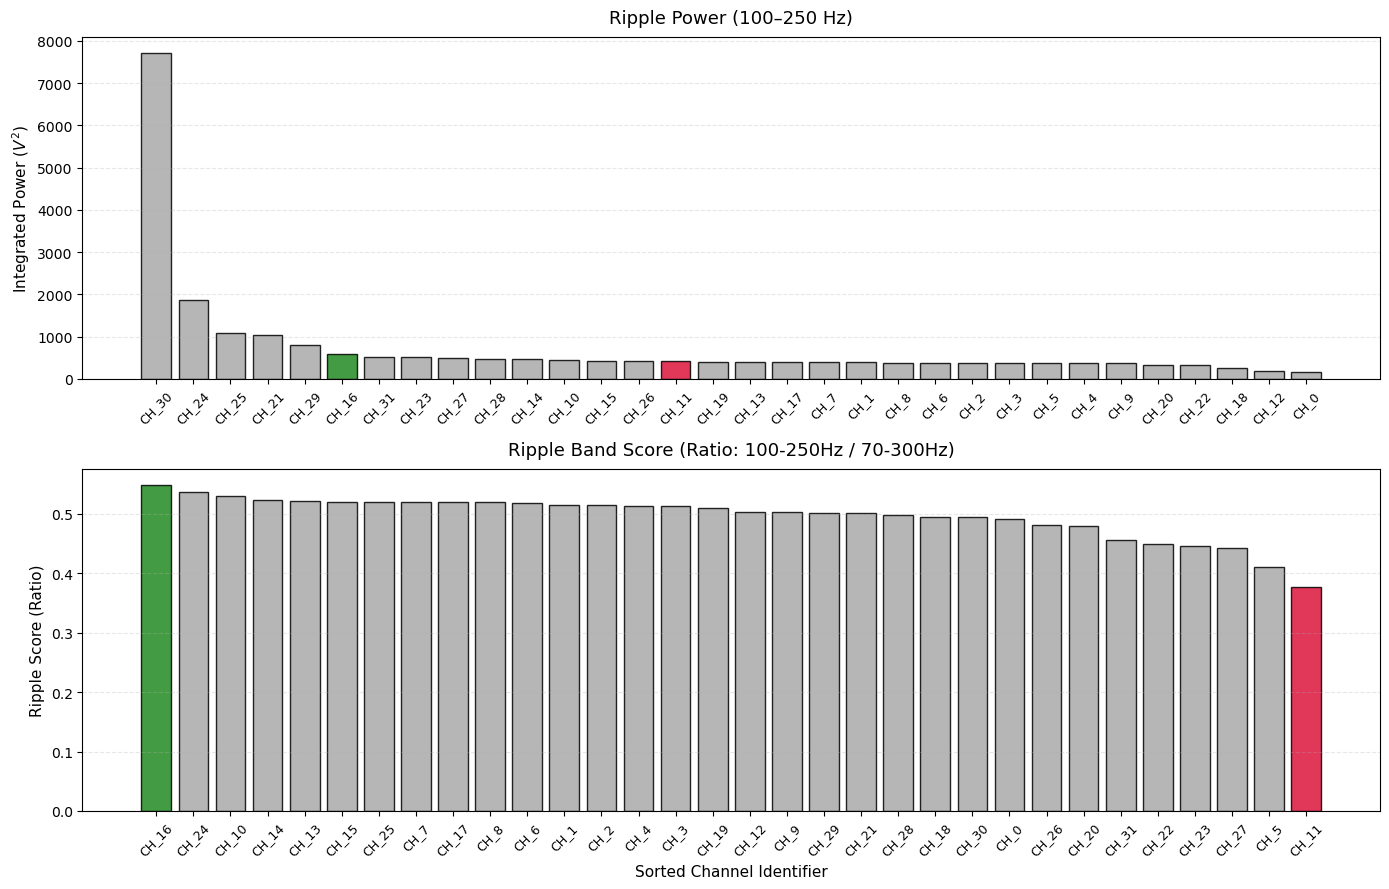

In [38]:
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np

# Welch periodogram parameters
window_seconds = 4
nperseg = int(window_seconds * fs)  # 4-second window
noverlap = int(nperseg / 2)         # 50% overlap

channels = np.arange(n_voltage_channels)
ripple_powers = []
ripple_scores = []

print("Computing spectral metrics for 32 channels")

# 1. Compute spectral metrics sequentially (Using updated trapezoid integration)
for ch_idx in channels:
    freqs, psd = welch(filtered_data_cpu[ch_idx, :], fs=fs, 
                       window='hann', nperseg=nperseg, noverlap=noverlap)
    
    ripple_mask = (freqs >= 100) & (freqs <= 250)
    surrounding_mask = (freqs >= 70) & (freqs <= 300)
    
    # Solved DeprecationWarning: np.trapezoid replaces np.trapz
    r_power = np.trapezoid(psd[ripple_mask], freqs[ripple_mask])
    s_power = np.trapezoid(psd[surrounding_mask], freqs[surrounding_mask])
    
    score = r_power / s_power if s_power > 0 else 0
    
    ripple_powers.append(r_power)
    ripple_scores.append(score)

# Convert to numpy arrays for multi-indexing
ripple_powers = np.array(ripple_powers)
ripple_scores = np.array(ripple_scores)

# 2. Identify Target Reference Channels based strictly on Ripple Score
highest_score_idx = np.argmax(ripple_scores)
lowest_score_idx = np.argmin(ripple_scores)

highest_score_ch = channels[highest_score_idx]
lowest_score_ch = channels[lowest_score_idx]

# 3. Build a global color mapping locked to the channel's Ripple Score identity
channel_colors = {}
for ch in channels:
    if ch == highest_score_ch:
        channel_colors[ch] = 'forestgreen'
    elif ch == lowest_score_ch:
        channel_colors[ch] = 'crimson'
    else:
        channel_colors[ch] = 'darkgray'

# 4. Generate independent sorting matrices (Both from highest to lowest)
sort_indices_power = np.argsort(ripple_powers)[::-1]
sort_indices_score = np.argsort(ripple_scores)[::-1]

# Sort Power Data
sorted_channels_power = channels[sort_indices_power]
sorted_powers = ripple_powers[sort_indices_power]
colors_power_plot = [channel_colors[ch] for ch in sorted_channels_power]

# Sort Score Data
sorted_channels_score = channels[sort_indices_score]
sorted_scores = ripple_scores[sort_indices_score]
colors_score_plot = [channel_colors[ch] for ch in sorted_channels_score]

# 5. Multi-panel Visualization (Stacked layout)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
x_positions = np.arange(n_voltage_channels)

# Top Plot: Absolute Ripple Power (Sorted by Power)
channel_labels_power = [f"CH_{ch}" for ch in sorted_channels_power]
ax1.bar(x_positions, sorted_powers, color=colors_power_plot, edgecolor='black', alpha=0.85)
ax1.set_title("Ripple Power (100–250 Hz)", fontsize=13, pad=10)
ax1.set_ylabel("Integrated Power ($V^2$)", fontsize=11)
ax1.set_xticks(x_positions)
ax1.set_xticklabels(channel_labels_power, fontsize=9, rotation=45)
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')

# Bottom Plot: Relative Ripple Score (Sorted by Score)
channel_labels_score = [f"CH_{ch}" for ch in sorted_channels_score]
ax2.bar(x_positions, sorted_scores, color=colors_score_plot, edgecolor='black', alpha=0.85)
ax2.set_title("Ripple Band Score (Ratio: 100-250Hz / 70-300Hz)", fontsize=13, pad=10)
ax2.set_xlabel("Sorted Channel Identifier", fontsize=11)
ax2.set_ylabel("Ripple Score (Ratio)", fontsize=11)
ax2.set_xticks(x_positions)
ax2.set_xticklabels(channel_labels_score, fontsize=9, rotation=45)
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')

# Save downstream data matrices
pyramidal_channel_idx = highest_score_ch
highest_score = ripple_scores[highest_score_idx]
hippocampus_channel = filtered_data_cpu[pyramidal_channel_idx, :]

print("\n=== PYRAMIDAL LAYER CHANNEL DETERMINATION ===")
print(f"Green Bar -> Reference Channel (Highest Score): CH_{pyramidal_channel_idx} (Score: {highest_score:.4f})")
print(f"Red Bar   -> Worst Quality Channel (Lowest Score): CH_{lowest_score_ch} (Score: {ripple_scores[lowest_score_idx]:.4f})")

plt.tight_layout()
plt.show()

### SWR Detection

Based in Lopes dos Santos et al., 2025

In [58]:
def compute_swr_metrics(lfp_channel, fs=1000):
    time = np.linspace(0, len(lfp_channel)/fs, len(lfp_channel))
    
    # 1. Bandpass filtering (Ripple 100-250 Hz and Control band adjusted for fs=1000Hz)
    b_ripple, a_ripple = butter(4, [100, 250], btype='bandpass', fs=fs)
    ripple_band = filtfilt(b_ripple, a_ripple, lfp_channel)
    
    # Control band adjusted to 250-450 Hz because Nyquist limit is 500 Hz
    b_ctrl, a_ctrl = butter(4, [250, 450], btype='bandpass', fs=fs)
    control_band = filtfilt(b_ctrl, a_ctrl, lfp_channel)
    
    # 2. Hilbert transform for instantaneous envelopes and phase
    analytic_ripple = hilbert(ripple_band)
    envelope = np.abs(analytic_ripple)
    phase_unwrapped = np.unwrap(np.angle(analytic_ripple))
    
    ctrl_envelope = np.abs(hilbert(control_band))
    
    # 3. Detection thresholds
    median_env = np.median(envelope)
    threshold = 5 * median_env
    half_threshold = 2.5 * median_env
    
    # Peak detection (retaining only the highest peak within 20ms frames)
    min_distance_samples = int(0.020 * fs) 
    peaks, _ = find_peaks(envelope, height=threshold, distance=min_distance_samples)
    
    candidate_events = []
    
    # 4. Feature extraction per candidate event
    for peak in peaks:
        onset, offset = peak, peak
        while onset > 0 and envelope[onset] >= half_threshold: onset -= 1
        while offset < len(envelope) - 1 and envelope[offset] >= half_threshold: offset += 1
            
        duration = (offset - onset) / fs
        if duration <= 0: continue
            
        phase_diff_deg = np.degrees(phase_unwrapped[offset] - phase_unwrapped[onset])
        cycles = phase_diff_deg / 360.0
        mean_freq = cycles / duration
        
        ripple_power = (np.mean(envelope[onset:offset])) ** 2
        ctrl_power = (np.mean(ctrl_envelope[onset:offset])) ** 2
        
        # 5. Validation checks
        check_2 = mean_freq > 100
        check_3 = cycles >= 4
        check_4 = ripple_power >= (2 * ctrl_power)
        
        is_valid_swr = check_2 and check_3 and check_4
        
        candidate_events.append({
            'Peak_Sample': peak,
            'Onset_Time(s)': time[onset],
            'Offset_Time(s)': time[offset],
            'Duration(s)': duration,
            'Cycles': cycles,
            'Mean_Freq(Hz)': mean_freq,
            'Ripple_Power': ripple_power,
            'Ctrl_Power': ctrl_power,
            'Is_Valid_SWR': is_valid_swr
        })
        
    return pd.DataFrame(candidate_events), ripple_band, envelope

In [59]:
# Process the signal using the defined single-channel algorithm
df_events, ripple_band, envelope = compute_swr_metrics(hippocampus_channel, fs=fs)

# Print detection summaries
print(f"Total candidate events detected (exceeded 5x median): {len(df_events)}")

# Filter true SWR events that pass the remaining 3 strict criteria
true_swrs = df_events[df_events['Is_Valid_SWR'] == True].copy()
print(f"Validated SWR events (passed all remaining criteria): {len(true_swrs)}")

print("\n=== SWR EVENTS DATAFRAME PREVIEW ===")
display(true_swrs.head(10))

Total candidate events detected (exceeded 5x median): 3422
Validated SWR events (passed all remaining criteria): 80

=== SWR EVENTS DATAFRAME PREVIEW ===


,Peak_Sample,Onset_Time(s),Offset_Time(s),Duration(s),Cycles,Mean_Freq(Hz),Ripple_Power,Ctrl_Power,Is_Valid_SWR
1274,751046,751.035415,751.065415,0.030,4.204869,140.162312,6847.311871,3355.809448,True
2023,1032543,1032.524570,1032.617571,0.093,13.262488,142.607403,126418.556250,15325.711969,True
2024,1032565,1032.524570,1032.617571,0.093,13.262488,142.607403,126418.556250,15325.711969,True
2025,1032592,1032.524570,1032.617571,0.093,13.262488,142.607403,126418.556250,15325.711969,True
2026,1032625,1032.617571,1032.662571,0.045,6.133397,136.297705,10469.066954,1198.910811,True
2027,1032656,1032.617571,1032.662571,0.045,6.133397,136.297705,10469.066954,1198.910811,True
2029,1032985,1032.959571,1033.045571,0.086,11.598905,134.870987,36788.905274,4563.726705,True
2030,1033009,1032.959571,1033.045571,0.086,11.598905,134.870987,36788.905274,4563.726705,True
2031,1033039,1032.959571,1033.045571,0.086,11.598905,134.870987,36788.905274,4563.726705,True
2051,1038523,1038.508574,1038.545574,0.037,4.235726,114.479093,127374.375275,10123.986634,True


In [61]:
def nextpow2(i):
    n = 1
    while n < i: n *= 2
    return n

def closest(X, p):
    disp = X - p
    return np.argmin((disp*disp))

def cohen_cwt(signal, fs, freq_limits, num_frex, cycles_limits):
    time = np.arange(-2, 2 + 1/fs, 1/fs)
    frex = np.logspace(np.log10(freq_limits[0]), np.log10(freq_limits[1]), num_frex)
    s = np.logspace(np.log10(cycles_limits[0]), np.log10(cycles_limits[1]), num_frex) / (2 * np.pi * frex)

    n_wavelet = len(time)
    n_data = len(signal)
    n_convolution = n_wavelet + n_data - 1
    n_conv_pow2 = nextpow2(n_convolution)
    half_of_wavelet_size = n_wavelet // 2

    eegfft = fft(signal.values if isinstance(signal, pd.Series) else signal, n_conv_pow2)
    eegpower = np.zeros((num_frex, n_data))

    for fi in range(num_frex):
        wavelet = fft(
            np.sqrt(1 / (s[fi] * np.sqrt(np.pi))) *
            np.exp(2 * 1j * np.pi * frex[fi] * time) *
            np.exp(-time**2 / (2 * s[fi]**2)),
            n_conv_pow2
        )
        eegconv = ifft(wavelet * eegfft)
        eegconv = eegconv[:n_convolution]
        eegconv = eegconv[half_of_wavelet_size:-half_of_wavelet_size]
        eegpower[fi, :] = np.abs(eegconv)**2

    return frex, eegpower

def plot_eeg_spectrogram_on_ax(ax, power, freqs, time_range, vmin, vmax, hline_range):
    """Plots a linear frequency spectrogram without logarithmic scaling on the Y-axis."""
    im = ax.imshow(np.log10(power), # Log power for optimal color visibility
                   aspect='auto', origin='lower',
                   extent=[time_range[0], time_range[1], freqs.min(), freqs.max()],
                   vmin=vmin, vmax=vmax, cmap='jet')

    # Set exact linear limits for the frequency axis
    ax.set_ylim(freqs.min(), freqs.max())
    
    # White dashed indicators marking the target ripple band bounds
    ax.axhline(hline_range[0], color='w', linestyle='--', linewidth=3)
    ax.axhline(hline_range[1], color='w', linestyle='--', linewidth=3)


def plot_ripple_event_series(df_all, ripple_times, fs=1000, v_limit=(5, 7), height=None):
    for idx in range(len(ripple_times)):
        r_range = ripple_times.iloc[idx]
        
        # Center the dynamic event window inside a fixed 1-second display framework
        duration = r_range['Offset_Time(s)'] - r_range['Onset_Time(s)']
        factor = (1 - duration) / 2
        t_start = r_range['Onset_Time(s)'] - factor
        t_end = r_range['Offset_Time(s)'] + factor

        df_chunk = df_all[(df_all['time'] >= t_start) & (df_all['time'] <= t_end)]

        fig, axs = plt.subplots(4, 1, figsize=(20, 15))
        signals = ['Raw', 'Filtered', 'Envelope'] 

        for i, col in enumerate(signals):
            axs[i].plot(df_chunk['time'], df_chunk[col], color='black')
            
            # Shaded gray rectangle indicating the full biological duration of the event
            axs[i].axvspan(r_range['Onset_Time(s)'], r_range['Offset_Time(s)'], 
                           color='gray', alpha=0.3, lw=0, zorder=0)

            if col == 'Raw':
                axs[i].set_title(f"   {col}", loc='left', fontsize=20)
            elif col == 'Envelope':
                axs[i].set_title("   Envelope", loc='left', fontsize=20)
                if height is not None:
                    axs[i].axhline(height, color='black', linestyle='--')
            else:
                axs[i].set_title("   Filtered (100-250 Hz)", loc='left', fontsize=20)

            axs[i].set_ylabel('Amplitude (µV)', fontsize=15)
            for spine in ['right', 'top', 'bottom']:
                axs[i].spines[spine].set_visible(False)
            axs[i].xaxis.set_visible(False)
            axs[i].tick_params(axis='both', which='major', labelsize=12)

        # CWT Spectrogram configuration optimized for fs=1000Hz
        num_frex = 50
        cycles_limits = (7, 14)
        frex, eegpower = cohen_cwt(df_chunk['Raw'], fs, (80, 270), num_frex, cycles_limits)

        # Linear spectrogram execution
        plot_eeg_spectrogram_on_ax(axs[3], eegpower, frex,
                                   time_range=(t_start, t_end),
                                   vmin=v_limit[0], vmax=v_limit[1],
                                   hline_range=(100, 250)) 

        axs[3].set_title("   Spectrogram", loc='left', fontsize=20)
        axs[3].set_ylabel('Frequency (Hz)', fontsize=15)
        axs[3].set_xlabel('Time (s)', fontsize=15)
        axs[3].tick_params(axis='both', which='major', labelsize=12)

        plt.suptitle(f'Ripple {idx+1}', y=0.95, fontsize=25)
        plt.show()

Plotting the first 5 validated ripples...


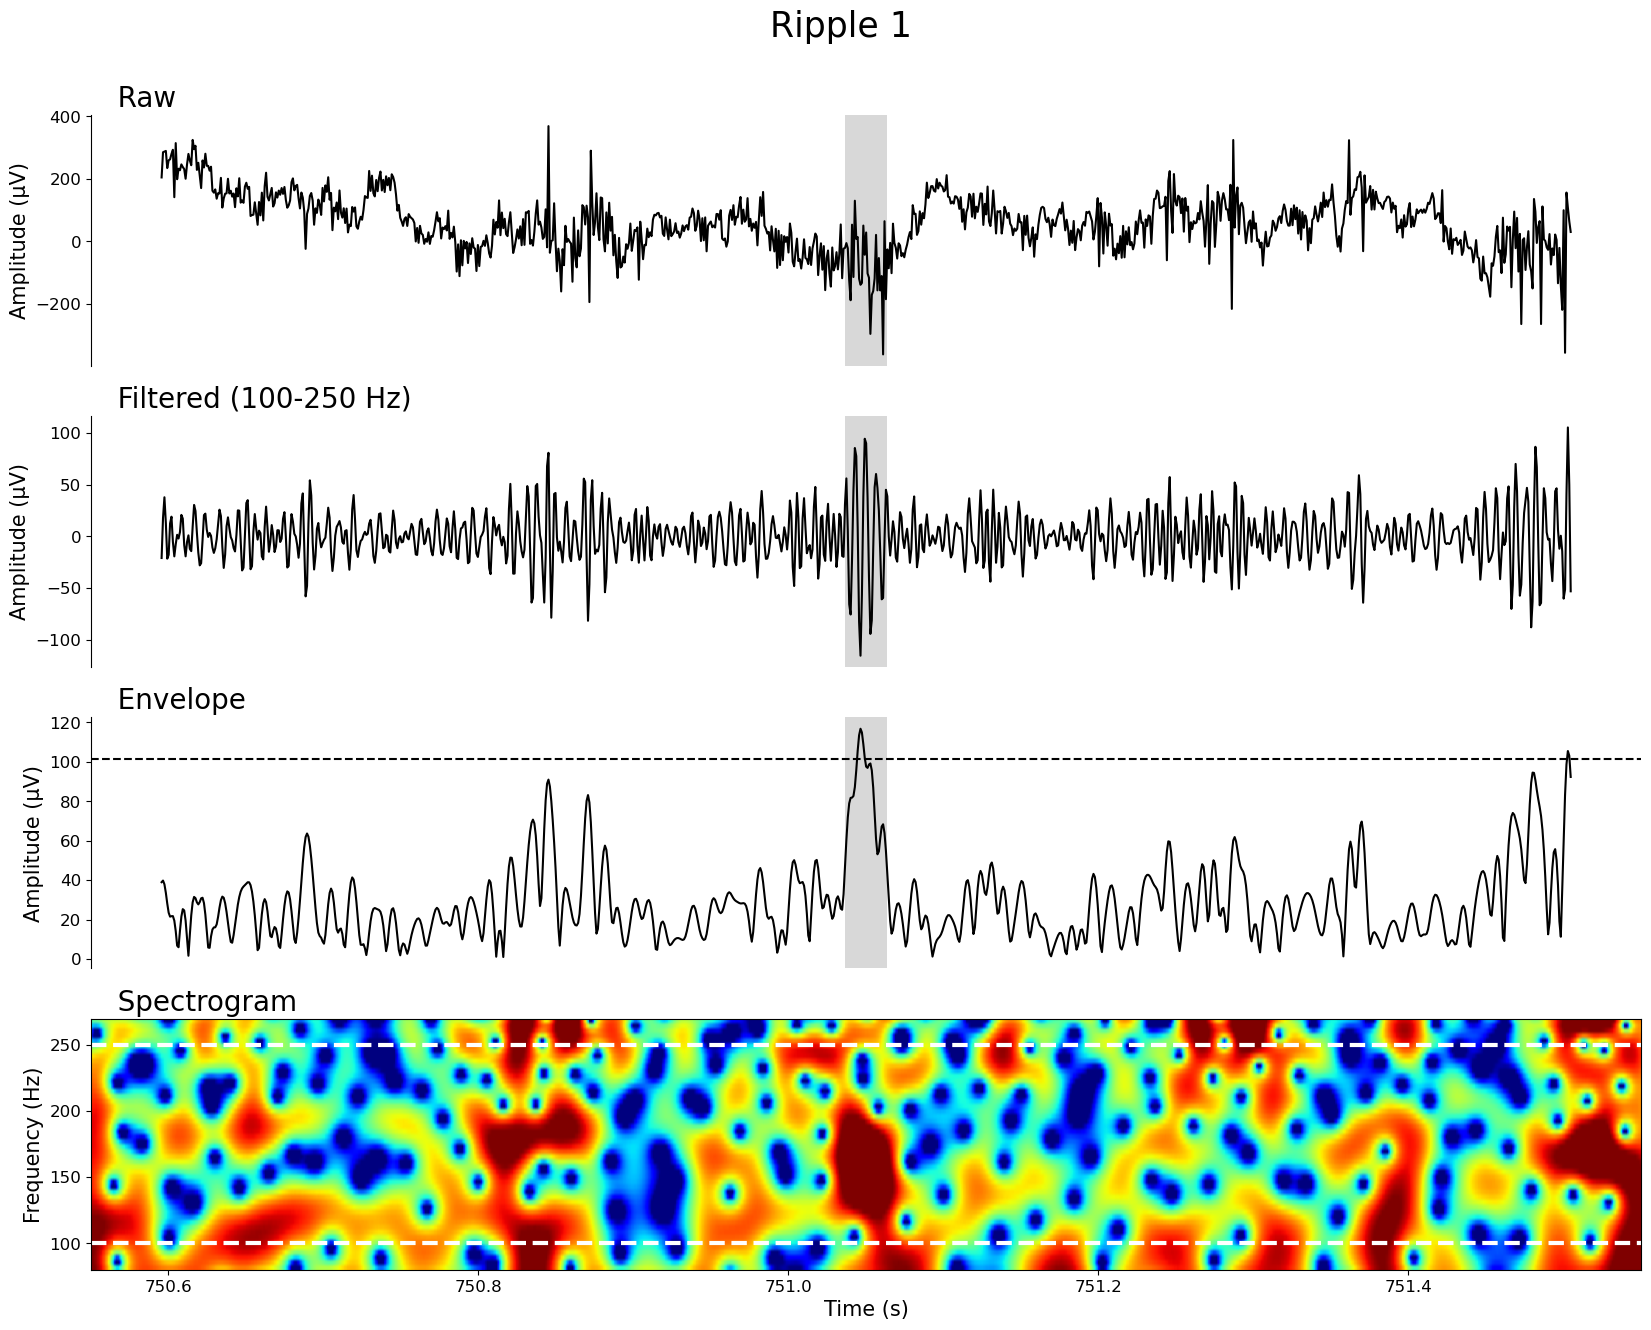

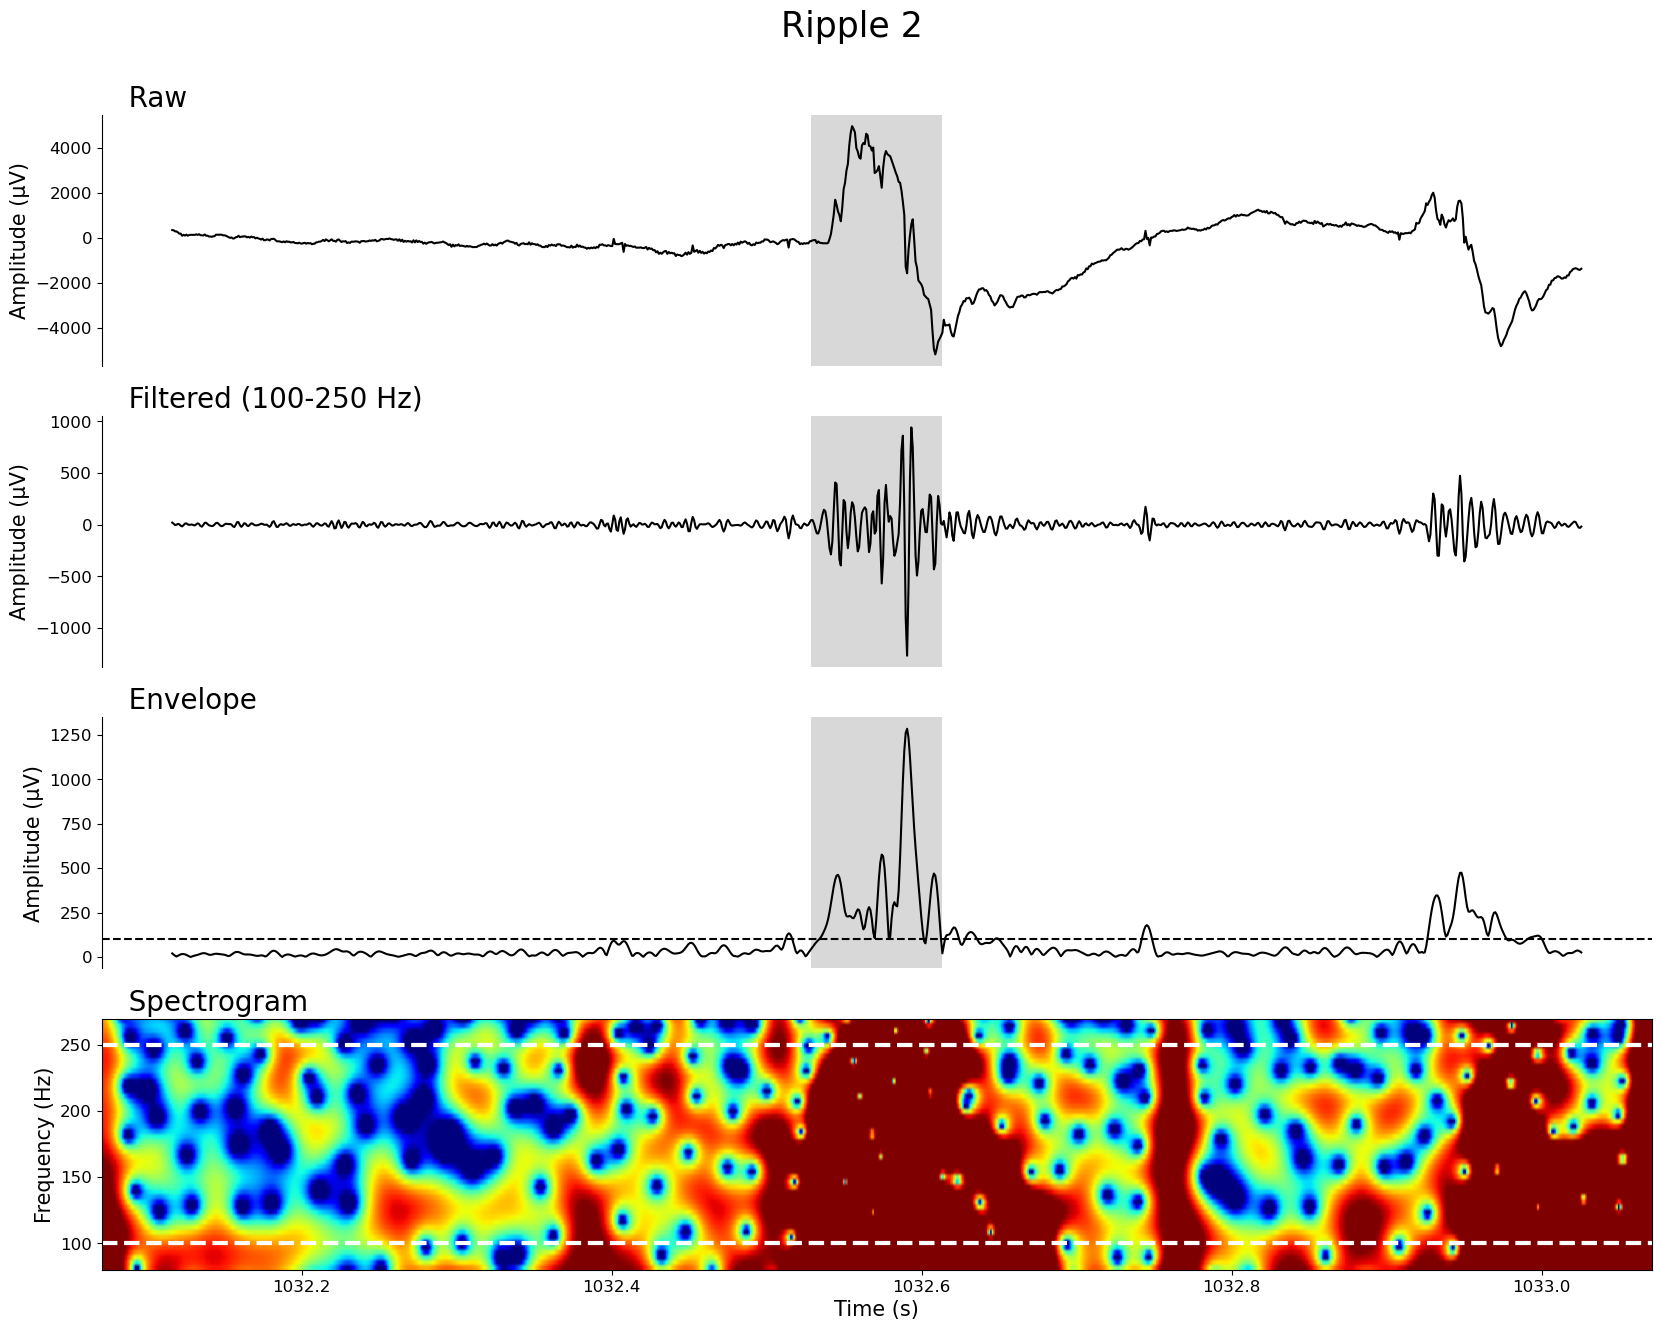

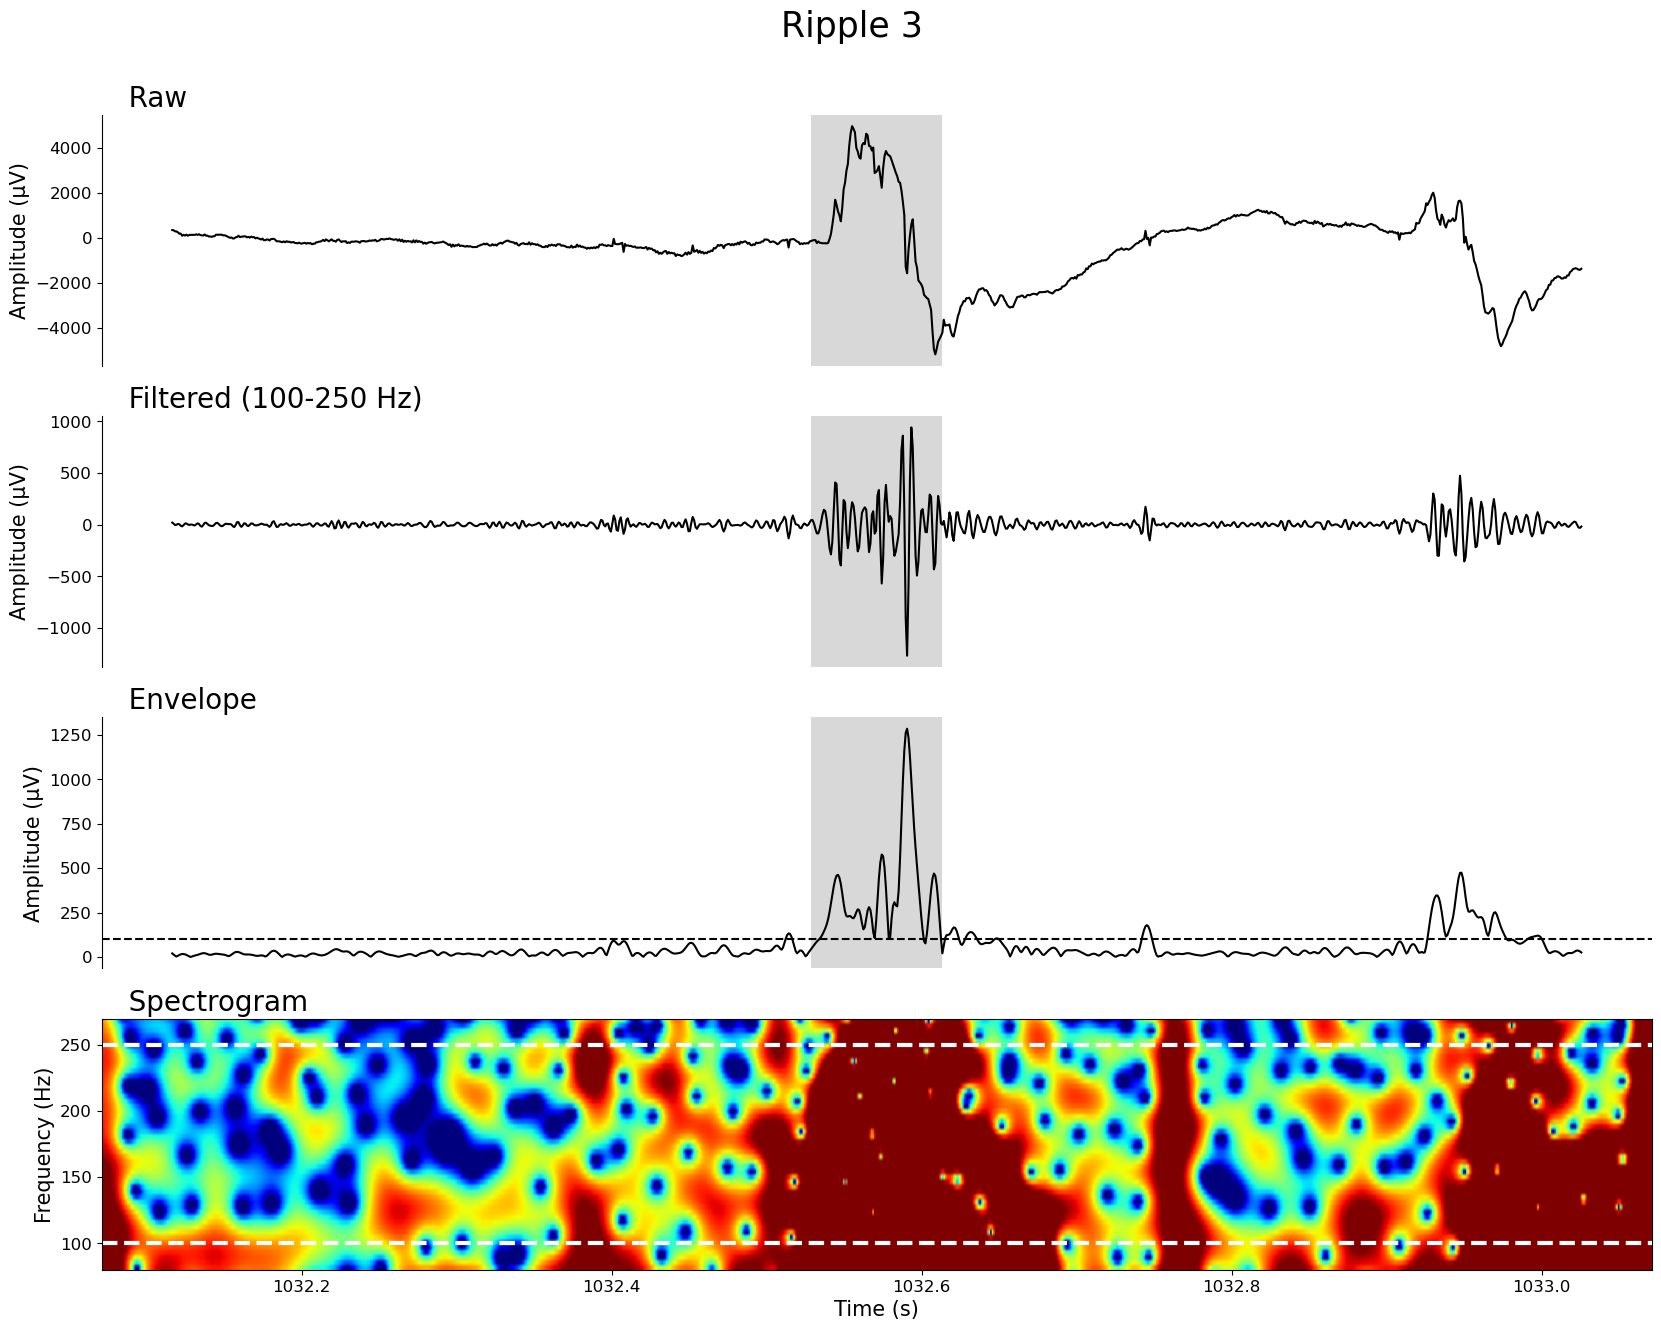

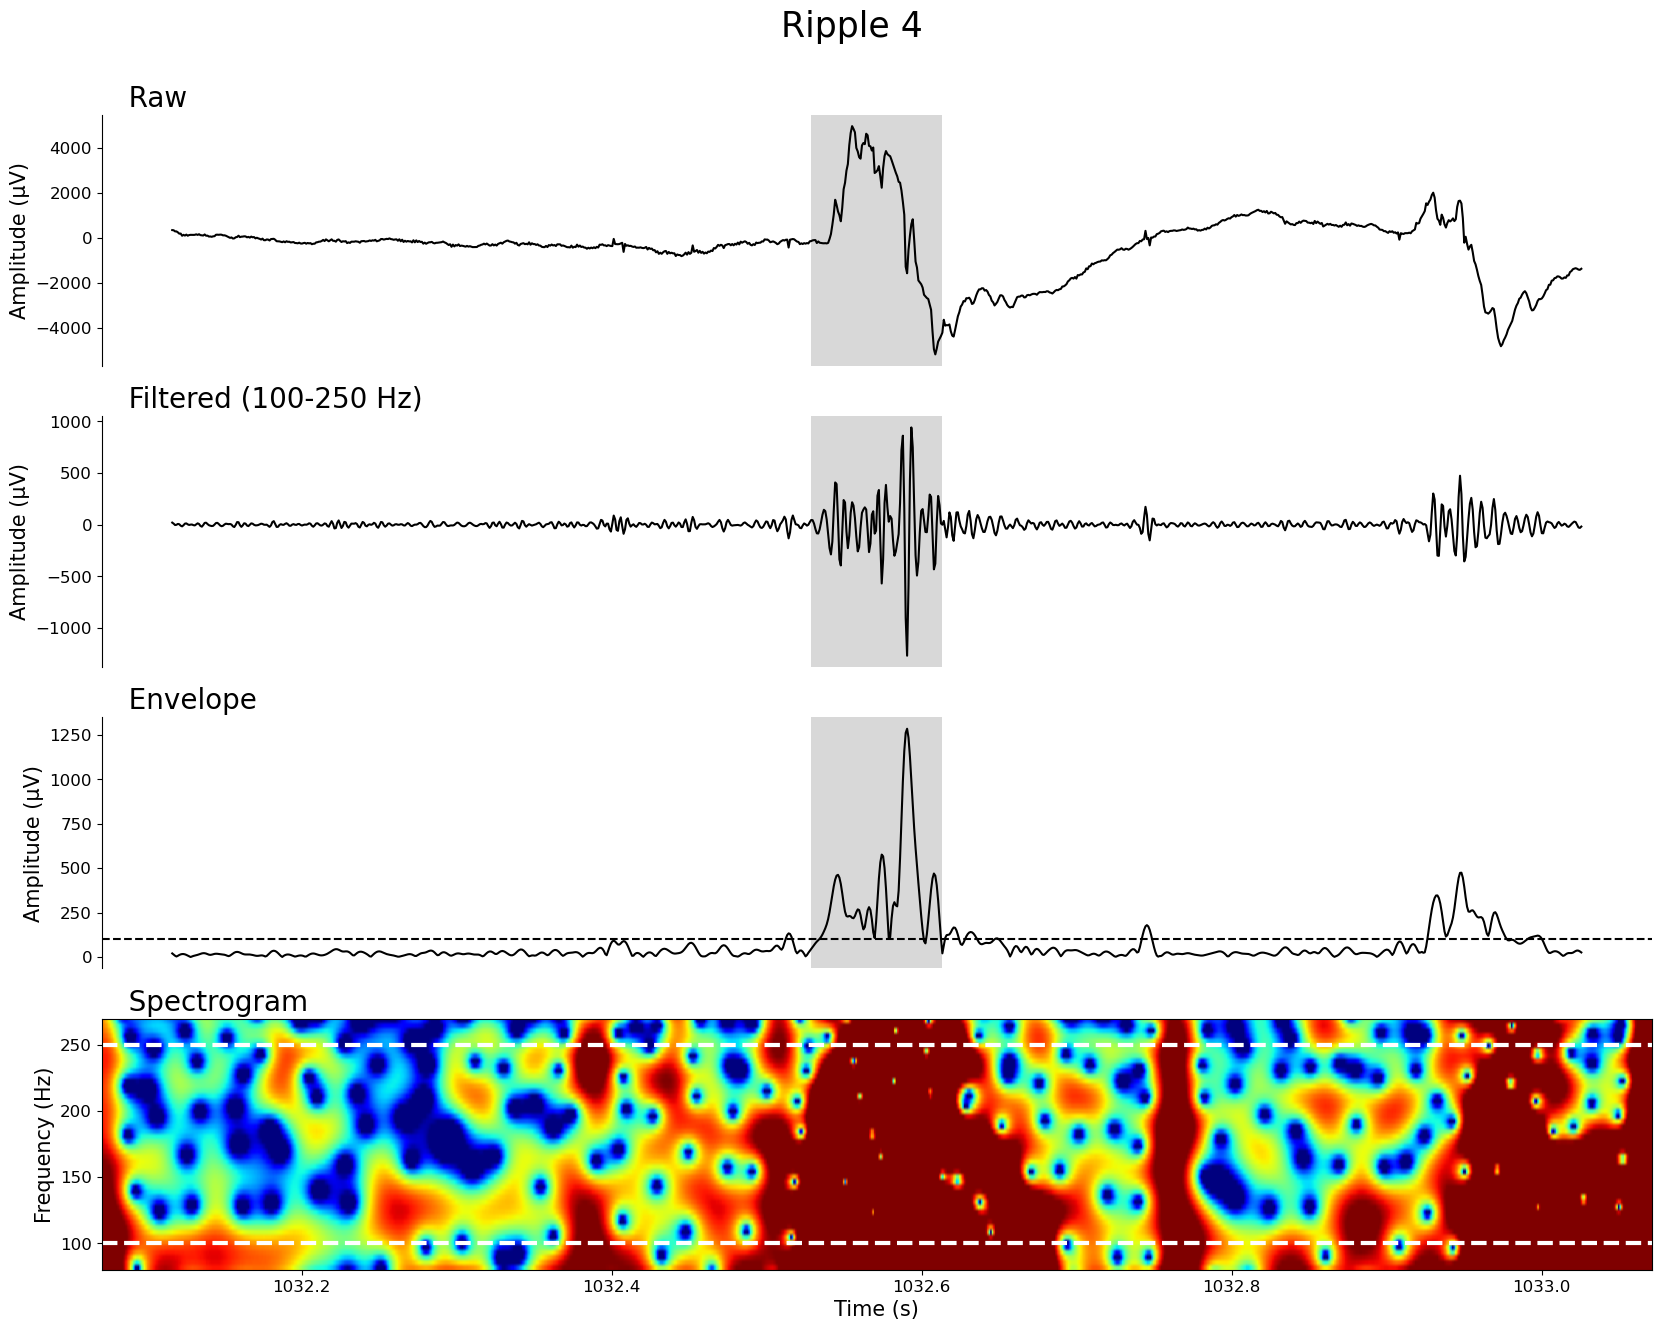

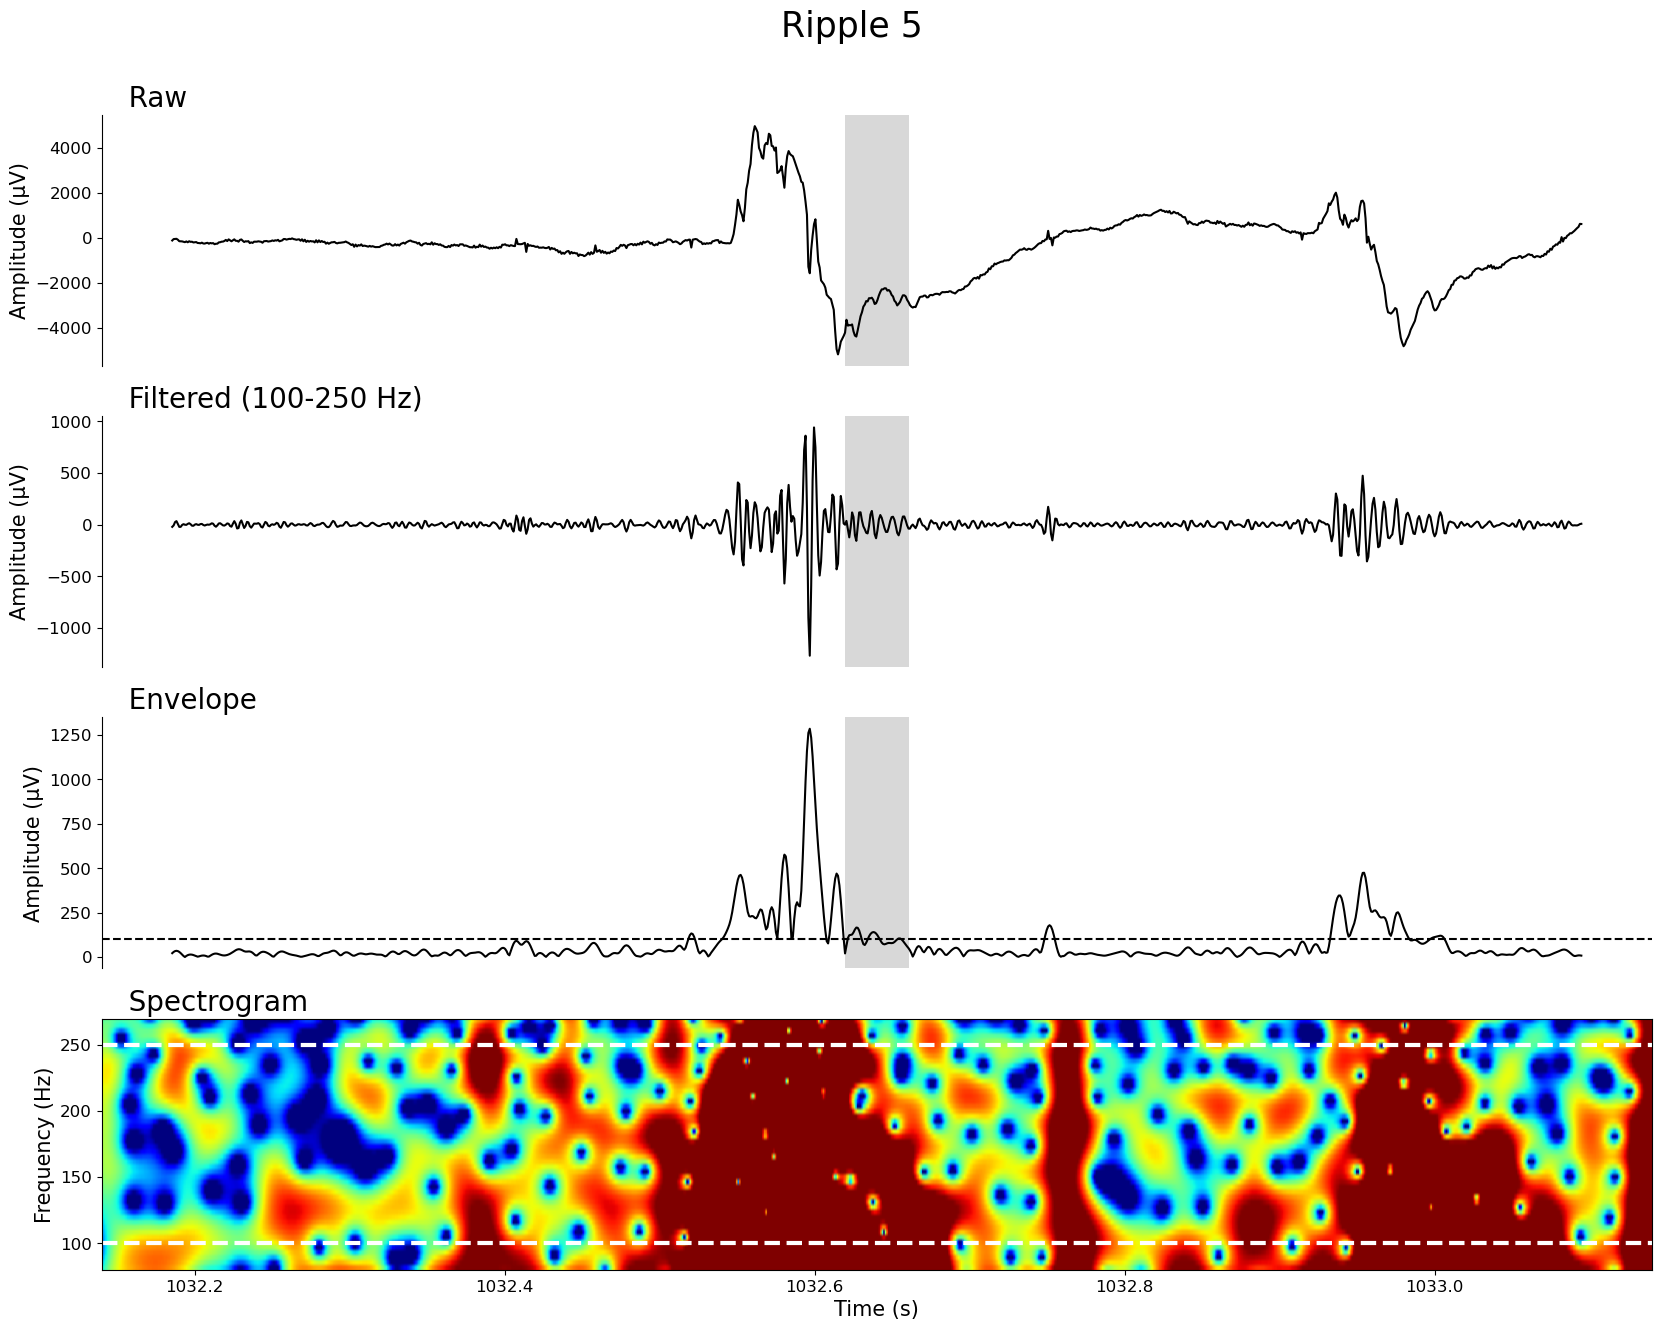

In [64]:
# 1. Generate the absolute time vector matching the current dataset lengths
time_array = np.linspace(0, len(hippocampus_channel) / fs, len(hippocampus_channel))

# 2. Reconstruct the absolute DataFrame grid using the 1000Hz metrics
df_full_signals = pd.DataFrame({
    'time': time_array,
    'Raw': hippocampus_channel,
    'Filtered': ripple_band,
    'Envelope': envelope 
})

# 3. Calculate plotting height threshold (5x median of the processed envelope)
detection_threshold = 5 * np.median(envelope)

# 4. Plot the first 5 verified ripples as an inspection benchmark
if len(true_swrs) > 0:
    print(f"Plotting the first {min(5, len(true_swrs))} validated ripples...")
    plot_ripple_event_series(df_full_signals, 
                             true_swrs.head(5), 
                             fs=fs, 
                             height=detection_threshold)
else:
    print("Cannot execute plotting block: No validated SWR events were detected in this pipeline.")